In [54]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences.base import TipVoltageSweep, Sequence, RFPowerSweep, RFPowerSweepVolLinear, \
                                            RigolAWGSweep, RFPowerSweepAWG, RFPowerSweepVolLinTipSwitched, \
                                            RFPowerSweepOnOff, RFPowerSweepOnOffTipOff, TipVoltageSweepDifferential
from edes.experiments.devices.base import Instrument
from edes.modules.variable_attenuator import var_attn_utils
from edes.utils.file_handling import load_latest_data
from edes.utils.utils import beep_jupyter
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
exp = Experiment('3layer_trapping_070926')

>>> ERROR connecting to RigolDG4062 at TCPIP::192.168.169.104::INSTR: [Errno 111] Connection refused
>>> ERROR initializing device AWG: 'RigolDG4062' object has no attribute 'instrument'
>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to ARTIQ Zotino.
>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> ERROR connecting to Keithley2100 at USB0::1510::8448::1243106::0::INSTR: No device found.
>>> ERROR connecting to SiglentSPD3303X_E at TCPIP::192.168.169.101::INSTR: [Errno 104] Connection reset by peer
>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> Connected to Valon at ASRL/dev/ttyUSB0::INSTR with frequency 1465714285 Hz and power 0 dBm.


In [3]:
exp.list_devices()

['Agilent', 'DAC', 'FEtip_PSU', 'Keithley', 'LNA_PSU', 'SSA', 'Valon']

100%|███████████████████████████████████████████| 10/10 [00:25<00:00,  2.57s/it]


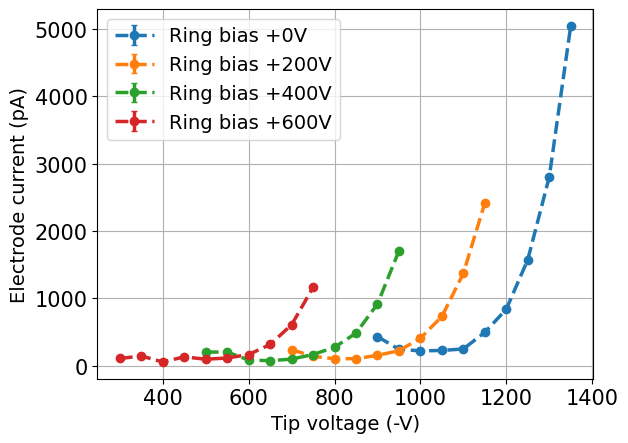

In [14]:
for Vpos in [0, 200, 400, 600]:
    Vneg_start = 900-Vpos
    Vneg_stop = 1400-Vpos
    tip_Vsweep = TipVoltageSweepDifferential(saving_dir=exp.saving_dir, 
                                 V_start=Vneg_start, V_stop=Vneg_stop, V_step=50, R=200e6, 
                                 N_avg=1, t_PSU_settle=2, t_meas_delay=0.2, 
                                 V_fixed=Vpos, ch_sweep='neg', ch_fixed='pos',
                                 FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Agilent)
    file = tip_Vsweep.run_save()
    plot_errbar(file['all_V'], np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', 
                xlabel='Tip voltage (-V)', ylabel='Electrode current (pA)', label=f'Ring bias +{Vpos}V')
    time.sleep(2)
plt.legend() 
plt.show()

100%|█████████████████████████████████████████████| 8/8 [00:52<00:00,  6.52s/it]


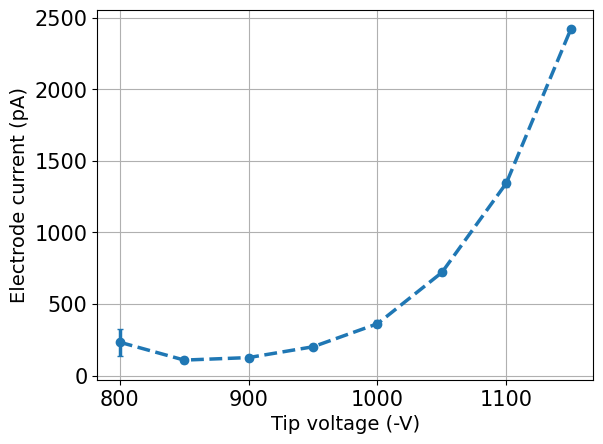

In [36]:
tip_Vsweep = TipVoltageSweepDifferential(saving_dir=exp.saving_dir, 
                                 V_start=800, V_stop=1170, V_step=50, R=200e6, 
                                 N_avg=8, t_PSU_settle=2, t_meas_delay=0.2, 
                                 V_fixed=200, ch_sweep='neg', ch_fixed='pos',
                                 FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Agilent)
file = tip_Vsweep.run_save()
plot_errbar(file['all_V'], np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', 
            xlabel='Tip voltage (-V)', ylabel='Electrode current (pA)', label=f'Ring bias +600V')

In [192]:
exp.SSA.select_mode('RTSA')
exp.SSA.set_N_avg(1)
exp.SSA.set_freq_span(10e3)
exp.SSA.set_freq_center(176.2190e6)
exp.SSA.set_div_scale(1)
exp.SSA.set_SWT(100e-3)
exp.SSA.set_RBW(100)
exp.SSA.set_ref_level(-65)
# freq, data = exp.SSA.measure_freq_spectrum()
# plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')

In [5]:
exp.SSA.select_mode('SA')
exp.SSA.set_N_avg(1)
exp.SSA.set_freq_span(0)
exp.SSA.set_freq_center(176.2190e6)
exp.SSA.set_div_scale(5)
exp.SSA.set_SWT(5)
exp.SSA.set_RBW(1e3)
exp.SSA.set_ref_level(-40)
# freq, data = exp.SSA.measure_freq_spectrum()
# plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')

In [38]:
exp.Valon.set_frequency(1465714285)
exp.Valon.set_power(10)
exp.Valon.output_on()

In [83]:
class RFPowerSweepOnOffDifferential(RFPowerSweepOnOff): 
    def __init__(self, name='RFPowerSweepOnOffDifferential', saving_dir=None,
                 P_load=10, P_detect=5, V_on=800, V_off=500, V_pos=600,
                 t_load=10, t_data=1, t_rest=1,
                 SSA_freq_center=None, SSA_freq_span = None,
                 SSA_RBW=30e3, N_avg=32,
                 Valon=None, SSA=None, FEtip_PSU=None,
                 display_progress=True,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, 
                         P_load=P_load, P_detect=P_detect, 
                         t_load=t_load, t_data=t_data, t_rest=t_rest,
                         N_avg=N_avg, V_on=V_on, V_off=V_off, 
                         SSA_freq_center=SSA_freq_center, SSA_freq_span=SSA_freq_span, 
                         SSA_RBW=SSA_RBW, 
                         Valon=Valon, SSA=SSA, FEtip_PSU=FEtip_PSU, 
                         display_progress=display_progress,
                         **kwargs)
        self.V_pos = V_pos

    def run(self):
        self.SSA.select_mode('SA')
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        self.FEtip_PSU.ramp_up_ch('pos', self.V_pos)
        self.FEtip_PSU.ramp_up(self.V_off)
        
        self.SSA.clear_averaging()
        data = self.SSA.get_full_trace()
        self.SSA.set_div_scale(5) 
        self.SSA.set_ref_level(max(data)+25)
        all_meas = []
        for _ in self.progress_bar(range(self.N_avg), disable=(not self.display_progress)):

            self.FEtip_PSU.set_voltage(self.V_on)
            self.Valon.output_on() 
            self.Valon.set_power(self.P_load)
            time.sleep(self.t_load)
            self.SSA.clear_averaging() 
            # self.SSA.get_full_trace()
            self.FEtip_PSU.set_voltage(self.V_off)
            self.Valon.set_power(self.P_detect)
            data = self.SSA.get_full_trace()
            all_meas.append(data)
            
            self.Valon.output_off()
            time.sleep(self.t_rest)

        self.FEtip_PSU.ramp_down(0)
        self.FEtip_PSU.ramp_down_ch('pos', 0)
        self.Valon.output_off()
        self.SSA.clear_averaging()

        return {'all_meas': np.array(all_meas)}

In [84]:
RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                 P_load=12.45, P_detect=7.12, V_on=850, V_off=500, V_pos=600,
                                 t_load=10, t_data=0.1, t_rest=10,
                                 SSA_freq_center=176.2190e6, SSA_freq_span=0,
                                 SSA_RBW=1e3, N_avg=50,
                                 Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                 display_progress=True)

In [85]:
exp.DAC.set_multipoles(Ex=0, U2=-1)
RF_sweep.set_parameters(Ex=0, U2=-1, background=False)
file = RF_sweep.run_save()
beep_jupyter()

RID: 10003
voltages loaded


100%|███████████████████████████████████████████| 50/50 [16:51<00:00, 20.23s/it]


In [86]:
np.sqrt(20/16/np.pi)

0.6307831305050401

In [51]:
for P_load in range(4,11,1):
    RF_sweep = RFPowerSweepOnOffDifferential(saving_dir=exp.saving_dir, 
                                     P_load=P_load, P_detect=P_load, V_on=850, V_off=850, V_pos=600,
                                     t_load=3, t_data=0.1, t_rest=0.1,
                                     SSA_freq_center=176.2190e6, SSA_freq_span=0,
                                     SSA_RBW=1e3, N_avg=20,
                                     Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                                     display_progress=True)

    RF_sweep.set_parameters(Ex=0.3, U2=-0.4, background=False)
    file = RF_sweep.run_save()
beep_jupyter()

100%|███████████████████████████████████████████| 20/20 [01:06<00:00,  3.31s/it]


In [52]:
exp.Valon.output_off()

In [ ]:
exp.DAC.ground_all() 

In [ ]:
beep_jupyter()

In [65]:
class RFPowerConstSweepTipSwitched(RFPowerSweepVolLinear): 
    def __init__(self, name='RFPowerConstSweepTipSwitched', P_valon_hold=0,
                 valon_settle=2, loading_time=3, measurement_time=5,
                 P_min_dBm=1, P_max_dBm=10, R=50, steps=800,  
                 V_on=1400, V_off=700, V_pos=600,
                 SSA_freq_center = None, SSA_freq_span = None,
                 SSA_RBW = None, SSA_SWT=None,
                 Valon=None, SSA=None, FEtip_PSU=None,
                 N_inner=3, N_outer=3, 
                 display_progress="outer",
                 **kwargs): 
        super().__init__(name, Valon=Valon, P_min_dBm=P_min_dBm, steps=steps,
                         P_max_dBm=P_max_dBm, R=R, V_on=V_on, V_off=V_off, 
                         SSA_freq_center=SSA_freq_center, SSA_freq_span=SSA_freq_span, SSA_RBW=SSA_RBW, SSA_SWT=SSA_SWT, SSA=SSA, FEtip_PSU=FEtip_PSU,
                         **kwargs)
        self.display_progress = display_progress
        self.disable_outer = self.display_progress != "outer"
        self.disable_pscan = self.display_progress != "Pscan"
        self.disable_inner = self.display_progress != "inner"

        self.valon_settle = valon_settle
        # check if measurement_time >= loading_time. If not, throw an error
        if measurement_time < loading_time:
            raise ValueError(f"Invalid times: measurement_time ({measurement_time}) must be greater than or equal to loading_time ({loading_time}).")
        self.loading_time = loading_time
        self.measurement_time = measurement_time
        self.N_inner = N_inner
        self.N_outer = N_outer
        self.V_pos = V_pos
        self.P_valon_hold = P_valon_hold
        self.Valon.set_power(self.P_valon_hold)
        self.Valon.output_on()
        

    def run(self):
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        self.FEtip_PSU.ramp_up_ch('pos', self.V_pos)
        self.FEtip_PSU.ramp_up(self.V_on)
        self.SSA.clear_averaging()
        self.SSA.trigger_off()

        # self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        voltage_scan = np.linspace(self.V_min, self.V_max, self.steps)
        dBm_scan = np.around(Vp_to_dBm(voltage_scan, R=self.R), 5)
        # all_meas = []
        # all_t_meas= [] 
        results = {'dBm_scan': dBm_scan}
        self.Valon.set_power(dBm_scan[0])
        self.Valon.output_on()
        
        # print(f"Starting experiment. SA will sweep continuously for {self.measurement_time}. Loading time is {self.loading_time}.")
        for repetition in self.progress_bar(range(self.N_outer), disable=self.disable_outer, desc='>>> Outer averaging'):
            # outer_meas = []
            # outer_t_meas = []
            for dBm_Valon in self.progress_bar(dBm_scan, disable=self.disable_pscan, desc='>>> Power scans'):
                # inner_meas = []
                # inner_t_meas = []
                self.Valon.set_power(dBm_Valon)
                self.Valon.output_on()
                time.sleep(self.valon_settle)
                for average in self.progress_bar(range(self.N_inner), disable=self.disable_inner, desc='>>> Inner repetitions'):
                    
                    tip_is_on = True
                    t0 = time.perf_counter()
                    all_inner = [] 
                    all_t_inner = []
                    while True:
                        now = time.perf_counter() - t0
                        # 1. Check if it's time to stop the entire experiment
                        if now >= self.measurement_time:
                            break
                        # 2. Check if it's time to turn the tip off (Only execute once)
                        # if tip_is_on and now >= self.loading_time:
                        #     self.FEtip_PSU.set_voltage(self.V_off)
                        #     tip_is_on = False # Prevents this block from triggering again
                        # 3. Capture SA Data immediately (This blocks only for the hardware sweep duration)
                        sweep_start_time = time.perf_counter() - t0
                        data = self.SSA.get_full_trace()
                        sweep_stop_time = time.perf_counter() - t0
                        all_inner.append(data)
                        all_t_inner.append((sweep_start_time, sweep_stop_time))
                    # print(inner_t_meas)
                    # inner_meas.append()
                    # inner_t_meas.append()
                    results[f'dBm{dBm_Valon:.5f}_average{average}_repetition{repetition}_data'] = np.concatenate(all_inner)
                    results[f'dBm{dBm_Valon:.5f}_average{average}_repetition{repetition}_time'] = np.concatenate([np.linspace(all_t_inner[i][0], all_t_inner[i][1], len(all_inner[i])) for i in range(len(all_t_inner))])
            # all_meas.append(outer_meas)
            # all_t_meas.append(outer_t_meas)
        self.FEtip_PSU.ramp_down(0)
        self.Valon.set_power(0)
        self.Valon.output_off()
        return results ## fixing inhomogeneous array issue

In [80]:
RF_sweep = RFPowerConstSweepTipSwitched(
    saving_dir=exp.saving_dir,
    P_valon_hold=5,
    valon_settle=2, loading_time=0, measurement_time=30,
    P_min_dBm=13, P_max_dBm=6, steps=20,  
    V_on=850, V_off=500, V_pos=600,
    SSA_freq_center=176.2190e6, SSA_freq_span=0,
    SSA_RBW=1e3, SSA_SWT=0.1,
    Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
    N_inner=1, N_outer=1, 
    display_progress='Pscan'
)

In [82]:
RF_sweep = RFPowerConstSweepTipSwitched(
    saving_dir=exp.saving_dir,
    P_valon_hold=5,
    valon_settle=2, loading_time=0, measurement_time=30,
    P_min_dBm=13, P_max_dBm=6, steps=10,  
    V_on=850, V_off=500, V_pos=600,
    SSA_freq_center=176.2190e6, SSA_freq_span=0,
    SSA_RBW=1e3, SSA_SWT=0.1,
    Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
    N_inner=1, N_outer=1, 
    display_progress='Pscan'
)
for Ex in [-0.5, -0.25, 0, 0,25, 0,5]:
    exp.DAC.set_multipoles(Ex=Ex, U2=-0.4)
    RF_sweep.set_parameters(Ex=Ex, U2=-0.4, background=False)
    file = RF_sweep.run_save()

for U2 in [-1, -0.7, -0.4, -0.2, 0.5]:
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
beep_jupyter()


RID: 9990
voltages loaded


>>> Power scans: 100%|██████████████████████████| 10/10 [05:20<00:00, 32.09s/it]


RID: 9991
voltages loaded


>>> Power scans: 100%|██████████████████████████| 10/10 [05:20<00:00, 32.05s/it]


RID: 9992
voltages loaded


...

>>> Power scans: 100%|██████████████████████████| 10/10 [05:20<00:00, 32.09s/it]


RID: 10000
voltages loaded


>>> Power scans: 100%|██████████████████████████| 10/10 [05:20<00:00, 32.10s/it]


RID: 10001
voltages loaded


>>> Power scans: 100%|██████████████████████████| 10/10 [05:21<00:00, 32.10s/it]


In [110]:
exp.FEtip_PSU.ramp_down_ch('pos', 0)

In [109]:
for U2 in [-1, -0.9, -0.8, -0.7]:
    RF_sweep = RFPowerConstSweepTipSwitched(
        saving_dir=exp.saving_dir,
        P_valon_hold=5,
        valon_settle=2, loading_time=0, measurement_time=30,
        P_min_dBm=12.45, P_max_dBm=7.12, steps=2,  
        V_on=850, V_off=500, V_pos=600,
        SSA_freq_center=176.2190e6, SSA_freq_span=0,
        SSA_RBW=1e3, SSA_SWT=0.1,
        Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
        N_inner=1, N_outer=1, 
        display_progress='Pscan'
    )
    exp.DAC.set_multipoles(Ex=0, U2=U2)
    RF_sweep.set_parameters(Ex=0, U2=U2, background=False)
    file = RF_sweep.run_save()
beep_jupyter()


RID: 10015
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.07s/it]


RID: 10016
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.06s/it]


RID: 10017
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.09s/it]


RID: 10018
voltages loaded


>>> Power scans: 100%|████████████████████████████| 2/2 [01:04<00:00, 32.11s/it]


In [111]:
exp.Valon.output_off()